# Carregamento das bibliotecas

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1775609559.772747   23887 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775609559.776722   23887 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775609560.212915   23887 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775609561.508780   23887 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Carregamento dos dados

In [2]:
from scipy.io import loadmat

dados = loadmat('Dados.mat')

print(dados.keys())

dict_keys(['__header__', '__version__', '__globals__', 'A'])


In [3]:
print(dados['A'])
print(dados['A'].shape)

[[15031.41]
 [12754.93]
 [16581.87]
 [15573.27]
 [16056.71]
 [16279.71]
 [15812.41]
 [16406.57]
 [15215.39]
 [15634.63]
 [15757.18]
 [15747.87]
 [13735.74]
 [15861.16]
 [15189.98]
 [ 5705.19]
 [16142.99]
 [16409.95]
 [13480.1 ]
 [12655.52]
 [14314.51]
 [16221.44]
 [15783.5 ]
 [16442.9 ]
 [16450.64]
 [16571.  ]
 [16978.1 ]
 [14974.75]
 [15373.42]
 [16155.25]
 [16418.15]
 [16749.53]
 [13154.81]
 [16422.71]
 [16245.62]
 [16087.99]
 [14525.89]
 [14263.13]
 [15867.35]
 [15927.83]
 [15533.32]
 [14953.39]
 [16074.39]
 [16488.89]
 [16220.98]
 [14928.18]
 [12038.96]
 [14463.45]
 [13119.6 ]
 [11663.77]
 [15615.32]
 [13034.86]
 [15971.75]
 [15786.16]
 [14530.55]
 [14568.05]
 [15884.03]
 [14511.91]
 [15696.07]
 [15619.17]
 [15497.15]
 [15791.78]
 [15833.04]
 [14605.04]
 [12926.68]
 [12195.81]
 [ 9277.27]
 [13569.41]
 [15216.03]
 [15369.85]
 [15195.72]
 [15088.29]
 [15430.53]
 [14954.8 ]
 [13094.69]
 [ 9099.95]
 [11207.23]
 [11992.55]
 [14646.85]
 [ 5350.36]
 [16195.19]
 [15569.98]
 [15748.61]
 [15

In [4]:
x = np.arange(1, len(dados['A']) + 1)
y = np.array(dados['A']/1000).flatten()
y.shape

(939,)

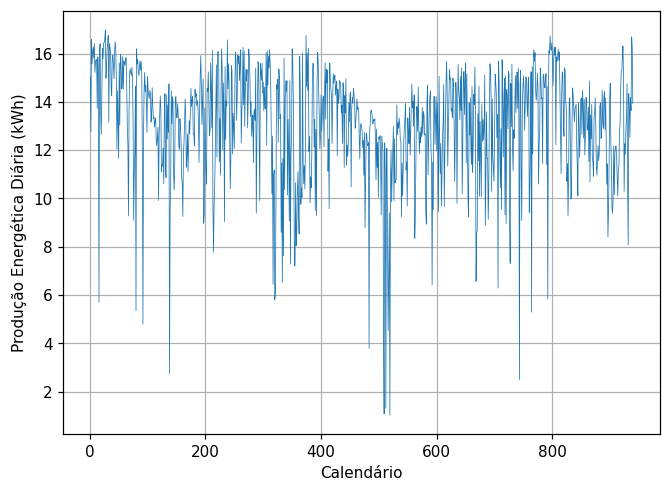

In [5]:
plt.figure(figsize=(7, 5), dpi=110)
plt.plot(x, y, linewidth=0.5)
plt.xlabel("Calendário")
plt.ylabel("Produção Energética Diária (kWh)")
plt.grid()


# Aplicação da média móvel nos dados

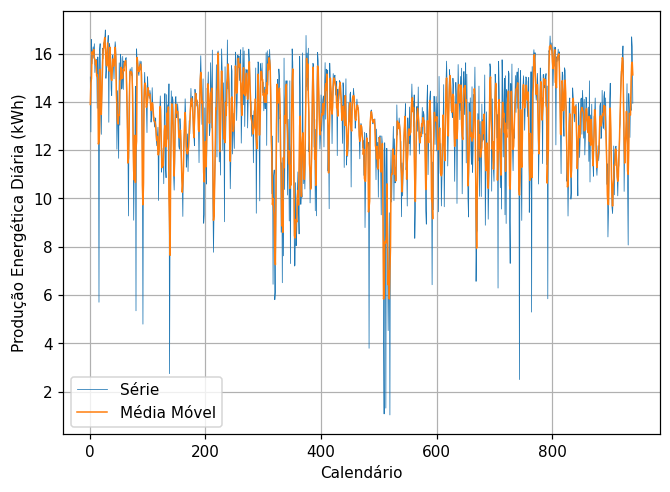

In [6]:
ymm = pd.Series(y).rolling(window=3, center=True, min_periods=1).mean().to_numpy()
#ymm = np.convolve(y, np.ones(3)/3, mode='same')
plt.figure(figsize=(7,5), dpi=110)
plt.plot(x, y, linewidth=0.5)
plt.plot(x, ymm, linewidth=1.0)
plt.xlabel("Calendário")
plt.ylabel("Produção Energética Diária (kWh)")
plt.legend(["Série", "Média Móvel"])
plt.grid()


# Divisão dos dados para treino e teste

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, ymm_train, ymm_test = train_test_split (x, ymm, test_size =0.3, shuffle=False)

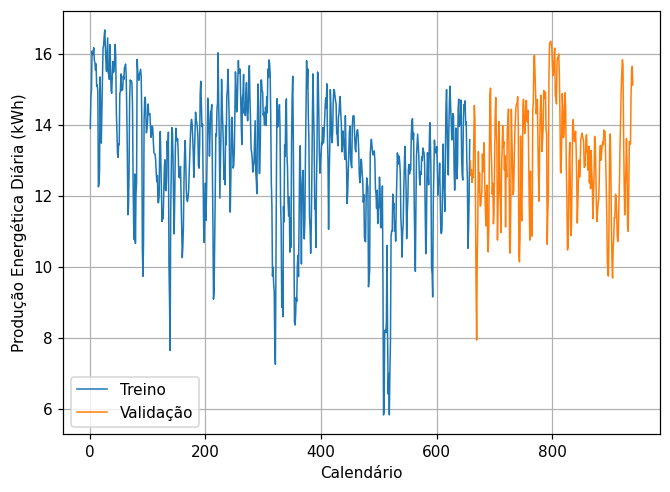

In [8]:
plt.figure(figsize=(7,5), dpi=110)
plt.plot(x_train, ymm_train, linewidth=1.0)
plt.plot(x_test, ymm_test, linewidth=1.0)
plt.xlabel("Calendário")
plt.ylabel("Produção Energética Diária (kWh)")
plt.grid()
plt.legend(["Treino", "Validação"])

# Normalização dos dados

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler_ymm = MinMaxScaler()

ymm_train_scaled = scaler_ymm.fit_transform(ymm_train.reshape(-1, 1))
ymm_test_scaled = scaler_ymm.transform(ymm_test.reshape(-1, 1))



# Criação das janelas deslizantes (curto, médio e longo prazo)

In [13]:
from numpy.lib.stride_tricks import sliding_window_view

def gerar_datasets(serie, n_passado, n_futuro):
    tamanho_janela = n_passado + n_futuro
    janelas = sliding_window_view(serie, window_shape=tamanho_janela)
    
    x = janelas[:, :n_passado]
    
    y = janelas[:, n_passado:]
    
    return x, y

x_cp_train, y_target_cp_train = gerar_datasets(ymm_train_scaled.flatten(), 3, 1)
x_cp_test, y_target_cp_test = gerar_datasets(ymm_test_scaled.flatten(), 3, 1)

x_mp_train, y_target_mp_train = gerar_datasets(ymm_train_scaled.flatten(), 30, 7)
x_mp_test, y_target_mp_test = gerar_datasets(ymm_test_scaled.flatten(), 30, 7)

x_lp_train, y_target_lp_train = gerar_datasets(ymm_train_scaled.flatten(), 90, 30)
x_lp_test, y_target_lp_test = gerar_datasets(ymm_test_scaled.flatten(), 90, 30)


# Criação e Treinamento da rede neural

## Função para criar as redes neurais

In [19]:
def criar_mlp(neuronios_in, neuronios_out, neuronios, otimizador):
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Input(shape=(neuronios_in,))) 
    
    model.add(tf.keras.layers.Dense(neuronios, activation='relu'))
    model.add(tf.keras.layers.Dense(neuronios, activation='relu'))
    
    model.add(tf.keras.layers.Dense(neuronios_out, activation='linear'))
    
    model.compile(optimizer=otimizador, loss='mse', metrics=['mae'])
    return model


## Simulação das configurações para curto prazo

In [ ]:
# Lista de otimizadores
lista_otimizadores = ['adam', 'rmsprop', 'sgd', 'sgd_momentum', 'adagrad', 'adadelta', 'adamax', 'nadam', 'ftrl']

# Configurações de Neurônios e Batch
lista_neuronios = [5, 20, 100]
estratégias_batch = {
    'Batch':      len(x_cp_train), # Todo o dataset
    'Stochastic': 1,            # 1 amostra por vez
    'Mini-batch': 32            # Lote padrão
}


In [ ]:
resultados_cp = []

for n_ocultos in lista_neuronios:
    for nome_batch, b_size in estratégias_batch.items():
        for nome_otim in lista_otimizadores:
            
            # 1. Definir Otimizador
            if nome_otim == 'sgd_momentum':
                otim = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
            else:
                otim = tf.keras.optimizers.get(nome_otim) 
            
            # 2. Criar modelo
            model = criar_mlp(3, 1, n_ocultos, otim)
            
            # 3. Treinamento
            history = model.fit(x_cp_train, y_target_cp_train, 
                                epochs=200, 
                                batch_size=b_size, 
                                validation_split=0.1,
                                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], 
                                verbose=0)
            
            # 4. Predição
            y_pred = model.predict(x_cp_test, verbose=0)
            
            # 5. Desnormalizar para escala real
            y_pred_real = scaler_ymm.inverse_transform(y_pred)
            y_test_real = scaler_ymm.inverse_transform(y_target_cp_test)
            
            # 6. Calcular métricas na escala real
            MAPE = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
            mse_test, mae_test = model.evaluate(x_cp_test, y_target_cp_test, verbose=0)
            
            resultados_cp.append({
                'Neuronios': n_ocultos,
                'Algoritmo': nome_batch,
                'Otimizador': nome_otim,
                'MSE_Teste': mse_test,
                'MAE_Teste': mae_test,
                'MAPE_Teste': MAPE
            })
            
            print(f"Finalizado: {n_ocultos} neurônios | {nome_batch} | {nome_otim} | MAPE = {MAPE:.2f}%")
            
            # Limpar memória para a próxima iteração
            tf.keras.backend.clear_session()

# Transformar em DataFrame para análise
df_resultados_cp = pd.DataFrame(resultados_cp)


E0000 00:00:1775611257.862418   23887 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Finalizado: 5 neurônios | Batch | adam | MAPE = 7.24%
Finalizado: 5 neurônios | Batch | rmsprop | MAPE = 6.81%
Finalizado: 5 neurônios | Batch | sgd | MAPE = 8.69%
Finalizado: 5 neurônios | Batch | sgd_momentum | MAPE = 8.90%
Finalizado: 5 neurônios | Batch | adagrad | MAPE = 7.87%
Finalizado: 5 neurônios | Batch | adadelta | MAPE = 59.76%
Finalizado: 5 neurônios | Batch | adamax | MAPE = 40.63%
Finalizado: 5 neurônios | Batch | nadam | MAPE = 6.09%
Finalizado: 5 neurônios | Batch | ftrl | MAPE = 52.15%
Finalizado: 5 neurônios | Stochastic | adam | MAPE = 5.52%
Finalizado: 5 neurônios | Stochastic | rmsprop | MAPE = 5.55%
Finalizado: 5 neurônios | Stochastic | sgd | MAPE = 5.59%
Finalizado: 5 neurônios | Stochastic | sgd_momentum | MAPE = 5.82%
Finalizado: 5 neurônios | Stochastic | adagrad | MAPE = 8.46%
Finalizado: 5 neurônios | Stochastic | adadelta | MAPE = 7.66%
Finalizado: 5 neurônios | Stochastic | adamax | MAPE = 5.58%
Finalizado: 5 neurônios | Stochastic | nadam | MAPE = 9.92%

## Simulação das configurações para médio prazo

In [26]:
estratégias_batch = {
    'Batch':      len(x_mp_train), # Todo o dataset
    'Stochastic': 1,            # 1 amostra por vez
    'Mini-batch': 32            # Lote padrão
}

In [ ]:
resultados_mp = []

for n_ocultos in lista_neuronios:
    for nome_batch, b_size in estratégias_batch.items():
        for nome_otim in lista_otimizadores:
            
            # 1. Definir Otimizador
            if nome_otim == 'sgd_momentum':
                otim = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
            else:
                otim = tf.keras.optimizers.get(nome_otim) 
            
            # 2. Criar modelo
            model = criar_mlp(30, 7, n_ocultos, otim)
            
            # 3. Treinamento
            history = model.fit(x_mp_train, y_target_mp_train, 
                                epochs=200, 
                                batch_size=b_size, 
                                validation_split=0.1,
                                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], 
                                verbose=0)
            
            # 4. Predição
            y_pred = model.predict(x_mp_test, verbose=0)
            
            # 5. Redimensionar
            y_pred_flat = y_pred.reshape(-1, 1)
            y_test_flat = y_target_mp_test.reshape(-1, 1)

            # 6. Desnormalizar
            y_pred_real_flat = scaler_ymm.inverse_transform(y_pred_flat)
            y_test_real_flat = scaler_ymm.inverse_transform(y_test_flat)

            # 7. Redimensionar
            y_pred_real = y_pred_real_flat.reshape(y_pred.shape)
            y_test_real = y_test_real_flat.reshape(y_target_mp_test.shape)
            
            # 8. Calcular métricas na escala real
            MAPE = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
            mse_test, mae_test = model.evaluate(x_mp_test, y_target_mp_test, verbose=0)
            
            resultados_mp.append({
                'Neuronios': n_ocultos,
                'Algoritmo': nome_batch,
                'Otimizador': nome_otim,
                'MSE_Teste': mse_test,
                'MAE_Teste': mae_test,
                'MAPE_Teste': MAPE
            })
            
            print(f"Finalizado: {n_ocultos} neurônios | {nome_batch} | {nome_otim} | MAPE = {MAPE:.2f}%")
            
            # Limpar memória para a próxima iteração
            tf.keras.backend.clear_session()

# Transformar em DataFrame para análise
df_resultados_mp = pd.DataFrame(resultados_mp)


Finalizado: 5 neurônios | Batch | adam | MAPE = 10.23%
Finalizado: 5 neurônios | Batch | rmsprop | MAPE = 9.53%
Finalizado: 5 neurônios | Batch | sgd | MAPE = 11.45%
Finalizado: 5 neurônios | Batch | sgd_momentum | MAPE = 9.97%
Finalizado: 5 neurônios | Batch | adagrad | MAPE = 47.04%
Finalizado: 5 neurônios | Batch | adadelta | MAPE = 95.72%
Finalizado: 5 neurônios | Batch | adamax | MAPE = 28.52%
Finalizado: 5 neurônios | Batch | nadam | MAPE = 29.71%
Finalizado: 5 neurônios | Batch | ftrl | MAPE = 52.99%
Finalizado: 5 neurônios | Stochastic | adam | MAPE = 9.12%
Finalizado: 5 neurônios | Stochastic | rmsprop | MAPE = 9.12%
Finalizado: 5 neurônios | Stochastic | sgd | MAPE = 9.16%
Finalizado: 5 neurônios | Stochastic | sgd_momentum | MAPE = 9.06%
Finalizado: 5 neurônios | Stochastic | adagrad | MAPE = 11.04%
Finalizado: 5 neurônios | Stochastic | adadelta | MAPE = 18.63%
Finalizado: 5 neurônios | Stochastic | adamax | MAPE = 9.16%
Finalizado: 5 neurônios | Stochastic | nadam | MAPE =

## Simulação das configurações para longo prazo

In [28]:
estratégias_batch = {
    'Batch':      len(x_lp_train), # Todo o dataset
    'Stochastic': 1,            # 1 amostra por vez
    'Mini-batch': 32            # Lote padrão
}

In [ ]:
resultados_lp = []

for n_ocultos in lista_neuronios:
    for nome_batch, b_size in estratégias_batch.items():
        for nome_otim in lista_otimizadores:
            
            # 1. Definir Otimizador
            if nome_otim == 'sgd_momentum':
                otim = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
            else:
                otim = tf.keras.optimizers.get(nome_otim) 
            
            # 2. Criar modelo
            model = criar_mlp(90, 30, n_ocultos, otim)
            
            # 3. Treinamento
            history = model.fit(x_lp_train, y_target_lp_train, 
                                epochs=200, 
                                batch_size=b_size, 
                                validation_split=0.1,
                                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], 
                                verbose=0)
            
            # 4. Predição
            y_pred = model.predict(x_lp_test, verbose=0)
            
            # 5. Redimensionar
            y_pred_flat = y_pred.reshape(-1, 1)
            y_test_flat = y_target_lp_test.reshape(-1, 1)

            # 6. Desnormalizar
            y_pred_real_flat = scaler_ymm.inverse_transform(y_pred_flat)
            y_test_real_flat = scaler_ymm.inverse_transform(y_test_flat)

            # 7. Redimensionar
            y_pred_real = y_pred_real_flat.reshape(y_pred.shape)
            y_test_real = y_test_real_flat.reshape(y_target_lp_test.shape)
            
            # 8. Calcular métricas na escala real
            MAPE = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
            mse_test, mae_test = model.evaluate(x_lp_test, y_target_lp_test, verbose=0)
            
            resultados_lp.append({
                'Neuronios': n_ocultos,
                'Algoritmo': nome_batch,
                'Otimizador': nome_otim,
                'MSE_Teste': mse_test,
                'MAE_Teste': mae_test,
                'MAPE_Teste': MAPE
            })
            
            print(f"Finalizado: {n_ocultos} neurônios | {nome_batch} | {nome_otim} | MAPE = {MAPE:.2f}%")
            
            # Limpar memória para a próxima iteração
            tf.keras.backend.clear_session()

# Transformar em DataFrame para análise
df_resultados_lp = pd.DataFrame(resultados_lp)


Finalizado: 5 neurônios | Batch | adam | MAPE = 13.19%
Finalizado: 5 neurônios | Batch | rmsprop | MAPE = 12.44%
Finalizado: 5 neurônios | Batch | sgd | MAPE = 41.42%
Finalizado: 5 neurônios | Batch | sgd_momentum | MAPE = 16.63%
Finalizado: 5 neurônios | Batch | adagrad | MAPE = 52.76%
Finalizado: 5 neurônios | Batch | adadelta | MAPE = 55.11%
Finalizado: 5 neurônios | Batch | adamax | MAPE = 17.80%
Finalizado: 5 neurônios | Batch | nadam | MAPE = 12.30%
Finalizado: 5 neurônios | Batch | ftrl | MAPE = 53.85%
Finalizado: 5 neurônios | Stochastic | adam | MAPE = 9.67%
Finalizado: 5 neurônios | Stochastic | rmsprop | MAPE = 9.96%
Finalizado: 5 neurônios | Stochastic | sgd | MAPE = 9.90%
Finalizado: 5 neurônios | Stochastic | sgd_momentum | MAPE = 9.75%
Finalizado: 5 neurônios | Stochastic | adagrad | MAPE = 10.14%
Finalizado: 5 neurônios | Stochastic | adadelta | MAPE = 19.87%
Finalizado: 5 neurônios | Stochastic | adamax | MAPE = 9.68%
Finalizado: 5 neurônios | Stochastic | nadam | MAPE

# Análise dos resultados

## As 3 configurações mais favoráveis para cada caso

In [ ]:
# 1. Adicionar uma coluna identificadora em cada DataFrame
df_resultados_cp['Caso'] = 'Curto Prazo (3 in, 1 out)'
df_resultados_mp['Caso'] = 'Médio Prazo (30 in, 7 out)'
df_resultados_lp['Caso'] = 'Longo Prazo (90 in, 30 out)'

# 2. Concatenar todos em um único DataFrame global
df_global = pd.concat([df_resultados_cp, df_resultados_mp, df_resultados_lp], ignore_index=True)

# 3. Função para pegar os 3 melhores de cada grupo baseado no MAPE
ranking_final = df_global.sort_values(['Caso', 'MAPE_Teste']).groupby('Caso').head(3)

# 4. Formatação para exibição limpa
pd.options.display.float_format = '{:.4f}'.format
print("=== RANKING DOS 3 MELHORES MODELOS POR HORIZONTE DE TEMPO ===")
print(ranking_final[['Caso', 'Otimizador', 'Neuronios', 'Algoritmo', 'MAPE_Teste', 'MSE_Teste']])



=== RANKING DOS 3 MELHORES MODELOS POR HORIZONTE DE TEMPO ===
                            Caso    Otimizador  Neuronios   Algoritmo  \
43     Curto Prazo (3 in, 1 out)         nadam         20  Stochastic   
69     Curto Prazo (3 in, 1 out)        adamax        100  Stochastic   
42     Curto Prazo (3 in, 1 out)        adamax         20  Stochastic   
201  Longo Prazo (90 in, 30 out)  sgd_momentum         20  Stochastic   
178  Longo Prazo (90 in, 30 out)         nadam          5  Stochastic   
199  Longo Prazo (90 in, 30 out)       rmsprop         20  Stochastic   
144   Médio Prazo (30 in, 7 out)          adam        100  Stochastic   
117   Médio Prazo (30 in, 7 out)          adam         20  Stochastic   
150   Médio Prazo (30 in, 7 out)        adamax        100  Stochastic   

     MAPE_Teste  MSE_Teste  
43       5.5057     0.0071  
69       5.5066     0.0071  
42       5.5122     0.0071  
201      9.4976     0.0196  
178      9.5273     0.0199  
199      9.5606     0.0200  
144 

## Influência do número de neurônios

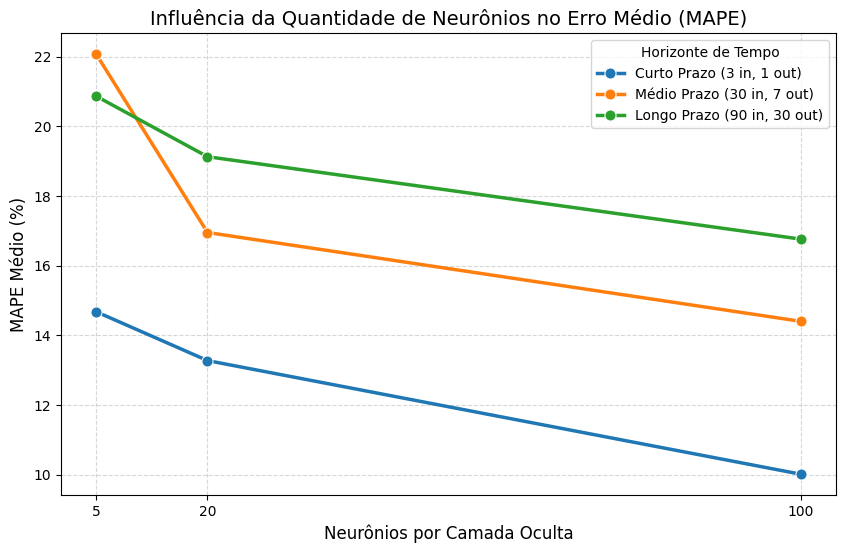

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# errorbar=None remove as linhas verticais de variação
sns.lineplot(data=df_global, x='Neuronios', y='MAPE_Teste', hue='Caso', 
             marker='o', markersize=8, linewidth=2.5, errorbar=None)

# Ajuste dos eixos para destacar a diferença entre 5, 20 e 100
plt.xticks([5, 20, 100])
plt.title('Influência da Quantidade de Neurônios no Erro Médio (MAPE)', fontsize=14)
plt.ylabel('MAPE Médio (%)', fontsize=12)
plt.xlabel('Neurônios por Camada Oculta', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Horizonte de Tempo')

plt.show()


## Influência do algoritmo de treinamento

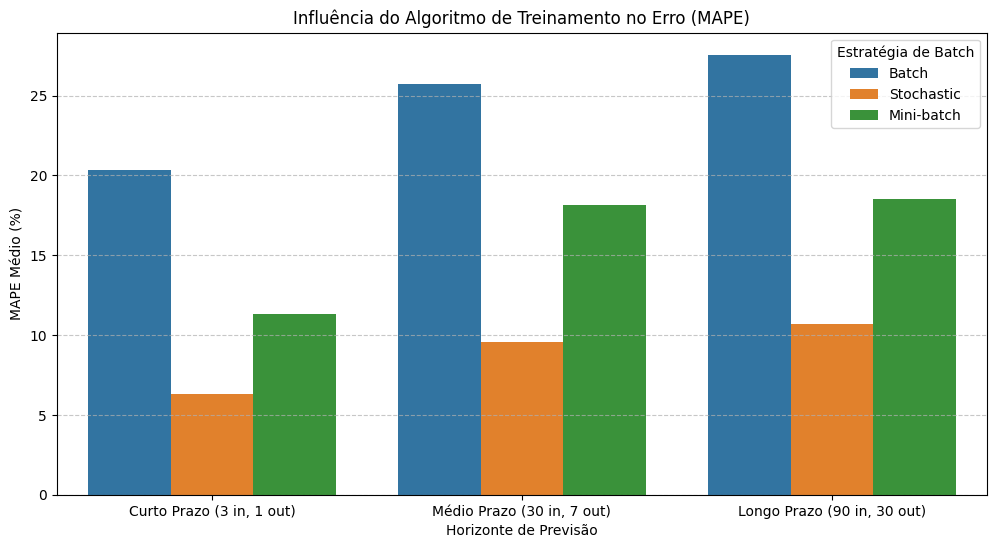

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Usando o erro médio (MAPE) para comparar os algoritmos
sns.barplot(data=df_global, x='Caso', y='MAPE_Teste', hue='Algoritmo', errorbar=None)

plt.title('Influência do Algoritmo de Treinamento no Erro (MAPE)')
plt.ylabel('MAPE Médio (%)')
plt.xlabel('Horizonte de Previsão')
plt.legend(title='Estratégia de Batch')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Influência dos otimizadores

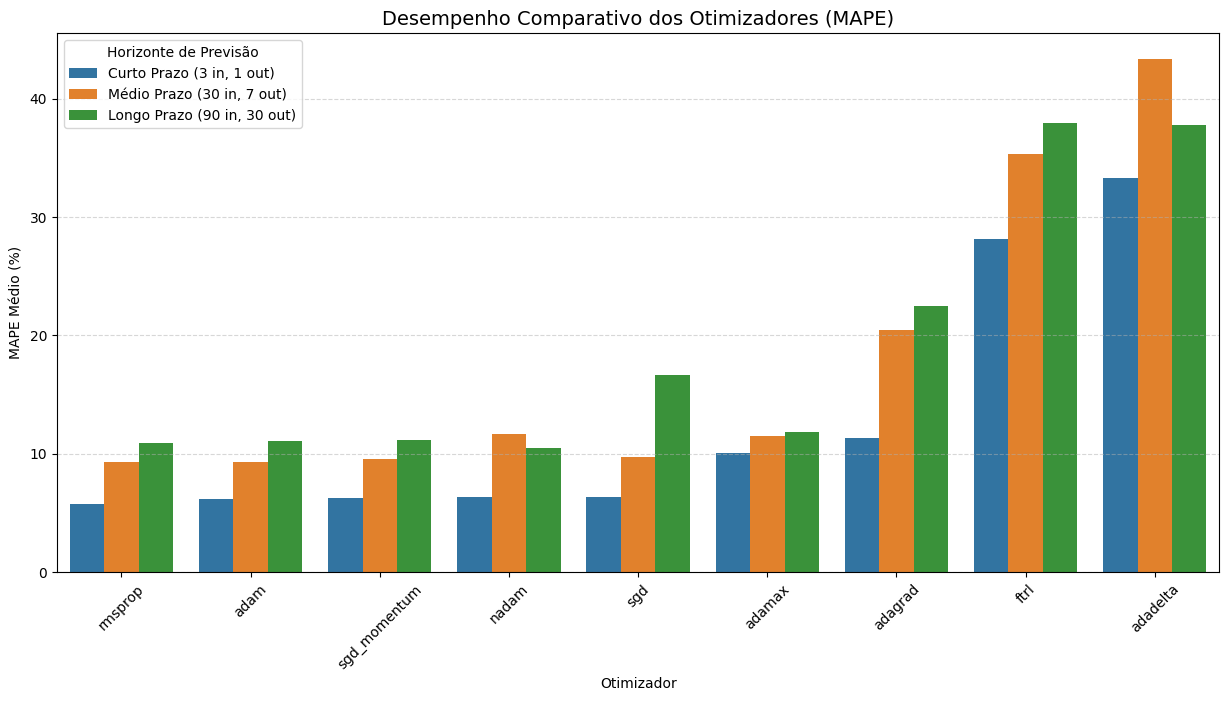

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
# Ordenando os otimizadores pelo MAPE médio para facilitar a leitura
ordem = df_global.groupby('Otimizador')['MAPE_Teste'].mean().sort_values().index

sns.barplot(data=df_global, x='Otimizador', y='MAPE_Teste', hue='Caso', 
            order=ordem, errorbar=None)

plt.title('Desempenho Comparativo dos Otimizadores (MAPE)', fontsize=14)
plt.ylabel('MAPE Médio (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Horizonte de Previsão')
plt.show()


# Previsão com as configurações mais favoráveis para cada caso

## Previsão de curto prazo

In [90]:
model = criar_mlp(3, 1, 20, "nadam")
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=25, restore_best_weights=True, verbose=1)
model.fit(x_cp_train, y_target_cp_train, validation_split=0.1, epochs=1000, callbacks=[early_stop], batch_size=1)
val_loss, val_mae = model.evaluate(x_cp_test, y_target_cp_test)
y_pred = model.predict(x_cp_test)
y_pred_real = scaler_ymm.inverse_transform(y_pred)
y_test_real = scaler_ymm.inverse_transform(y_target_cp_test)
MAPE = np.mean(np.abs((y_pred_real - y_test_real) / y_test_real))*100


Epoch 1/1000
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0158 - mae: 0.0845 - val_loss: 0.0063 - val_mae: 0.0636
Epoch 2/1000
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0081 - mae: 0.0678 - val_loss: 0.0062 - val_mae: 0.0641
Epoch 3/1000
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0082 - mae: 0.0672 - val_loss: 0.0061 - val_mae: 0.0638
Epoch 4/1000
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0078 - mae: 0.0652 - val_loss: 0.0054 - val_mae: 0.0580
Epoch 5/1000
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0077 - mae: 0.0651 - val_loss: 0.0054 - val_mae: 0.0589
Epoch 6/1000
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0078 - mae: 0.0652 - val_loss: 0.0052 - val_mae: 0.0579
Epoch 7/1000
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0079 - mae: 0.0669 - val_loss: 0.0054 - val_mae: 0.0586
Epoch 8/1000
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0078 - mae: 0.0655 - val_loss: 0.0064 - val_mae: 0.0650
Epoch 9/1000
588/588 ━━━━━━━━━━━━━━━━━━━

In [91]:
MAPE

np.float64(5.492119583922176)

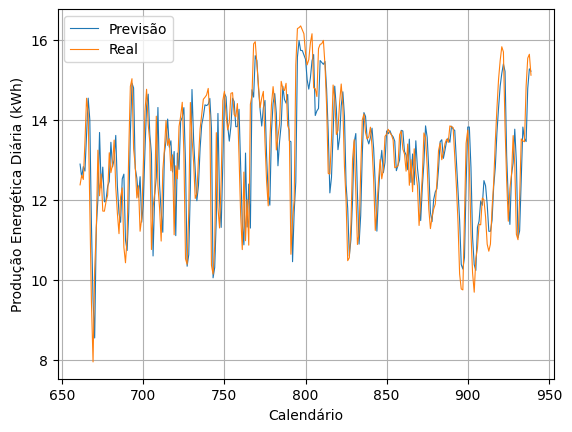

In [92]:
plt.Figure(figsize=(7, 5), dpi=110)
plt.plot(x_test[3:], y_pred_real, lw=0.8)
plt.plot(x_test[3:], y_test_real, lw=0.8)
plt.xlabel("Calendário")
plt.ylabel("Produção Energética Diária (kWh)")
plt.grid()
plt.legend(["Previsão", "Real"])

## Previsão de médio prazo

In [ ]:
model = criar_mlp(30, 7, 100, "adam")
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=50, restore_best_weights=True, verbose=1)
model.fit(x_mp_train, y_target_mp_train, validation_split=0.1, epochs=1000, callbacks=[early_stop], batch_size=1)
val_loss, val_mae = model.evaluate(x_mp_test, y_target_mp_test)

y_pred = model.predict(x_mp_test, verbose=0)

y_pred_flat = y_pred.reshape(-1, 1)
y_test_flat = y_target_mp_test.reshape(-1, 1)


y_pred_real_flat = scaler_ymm.inverse_transform(y_pred_flat)
y_test_real_flat = scaler_ymm.inverse_transform(y_test_flat)


y_pred_real = y_pred_real_flat.reshape(y_pred.shape)
y_test_real = y_test_real_flat.reshape(y_target_mp_test.shape)


MAPE = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
mse_test, mae_test = model.evaluate(x_mp_test, y_target_mp_test, verbose=0)

Epoch 1/1000
558/558 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0328 - mae: 0.1365 - val_loss: 0.0166 - val_mae: 0.1049
Epoch 2/1000
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0233 - mae: 0.1185 - val_loss: 0.0164 - val_mae: 0.1064
Epoch 3/1000
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0229 - mae: 0.1165 - val_loss: 0.0204 - val_mae: 0.1149
Epoch 4/1000
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0221 - mae: 0.1145 - val_loss: 0.0182 - val_mae: 0.1114
Epoch 5/1000
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0213 - mae: 0.1122 - val_loss: 0.0207 - val_mae: 0.1202
Epoch 6/1000
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0221 - mae: 0.1153 - val_loss: 0.0146 - val_mae: 0.0977
Epoch 7/1000
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0215 - mae: 0.1131 - val_loss: 0.0160 - val_mae: 0.1032
Epoch 8/1000
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0205 - mae: 0.1091 - val_loss: 0.0136 - val_mae: 0.0933
Epoch 9/1000
558/558 ━━━━━━━━━━━━━━━━━━━

In [85]:
MAPE

np.float64(8.550229310902079)

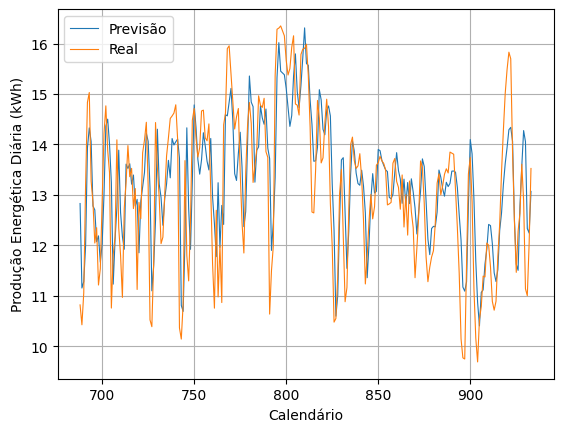

In [86]:
plt.Figure(figsize=(7, 5), dpi=110)
plt.plot(x_test[30:-6], y_pred_real[:, 0], lw=0.8)
plt.plot(x_test[30:-6], y_test_real[:, 0], lw=0.8)
plt.xlabel("Calendário")
plt.ylabel("Produção Energética Diária (kWh)")
plt.grid()
plt.legend(["Previsão", "Real"])

## Previsão de longo prazo

In [ ]:
model = criar_mlp(90, 30, 20, tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9))
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=100, restore_best_weights=True, verbose=1)
model.fit(x_lp_train, y_target_lp_train, validation_split=0.1, epochs=1000, callbacks=[early_stop], batch_size=1)
val_loss, val_mae = model.evaluate(x_lp_test, y_target_lp_test)

y_pred = model.predict(x_lp_test, verbose=0)


y_pred_flat = y_pred.reshape(-1, 1)
y_test_flat = y_target_lp_test.reshape(-1, 1)


y_pred_real_flat = scaler_ymm.inverse_transform(y_pred_flat)
y_test_real_flat = scaler_ymm.inverse_transform(y_test_flat)


y_pred_real = y_pred_real_flat.reshape(y_pred.shape)
y_test_real = y_test_real_flat.reshape(y_target_lp_test.shape)


MAPE = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
mse_test, mae_test = model.evaluate(x_lp_test, y_target_lp_test, verbose=0)

Epoch 1/1000
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0619 - mae: 0.1765 - val_loss: 0.0251 - val_mae: 0.1332
Epoch 2/1000
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0283 - mae: 0.1293 - val_loss: 0.0197 - val_mae: 0.1085
Epoch 3/1000
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0264 - mae: 0.1238 - val_loss: 0.0177 - val_mae: 0.1062
Epoch 4/1000
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0257 - mae: 0.1215 - val_loss: 0.0170 - val_mae: 0.1037
Epoch 5/1000
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0257 - mae: 0.1219 - val_loss: 0.0170 - val_mae: 0.1036
Epoch 6/1000
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0254 - mae: 0.1209 - val_loss: 0.0170 - val_mae: 0.1026
Epoch 7/1000
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0248 - mae: 0.1191 - val_loss: 0.0170 - val_mae: 0.1025
Epoch 8/1000
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0245 - mae: 0.1183 - val_loss: 0.0166 - val_mae: 0.1011
Epoch 9/1000
484/484 ━━━━━━━━━━━━━━━━━━━

In [88]:
MAPE

np.float64(10.234639784502884)

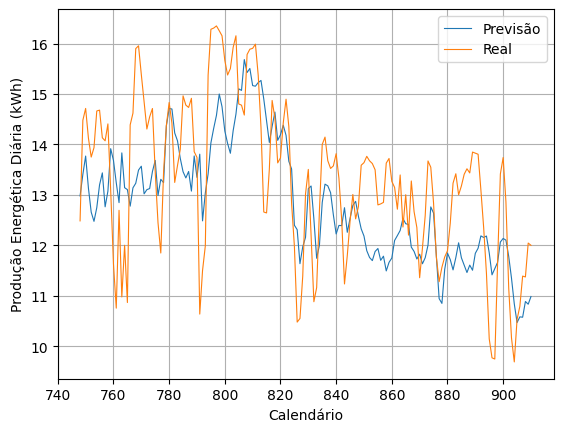

In [89]:
plt.Figure(figsize=(7, 5), dpi=110)
plt.plot(x_test[90:-29], y_pred_real[:, 0], lw=0.8)
plt.plot(x_test[90:-29], y_test_real[:, 0], lw=0.8)
plt.xlabel("Calendário")
plt.ylabel("Produção Energética Diária (kWh)")
plt.grid()
plt.legend(["Previsão", "Real"])